# Imports and Setup

In [1]:
# Imports
import os
from pathlib import Path
from urllib.parse import urlparse

from fastai.vision.all import *
from fastai.vision.gan import *
from fastai.vision.core import *

# imports from other notebooks
from ipynb.fs.full.Deink_00_Utils import *
from ipynb.fs.full.Deink_00_Utils import _get_sil_y 

Fastai Version: 2.7.12
Image Size: (480, 360)
Clean: True
Batch Size: 4


In [2]:
# Check that we have our GPU
device = get_torch_device()

Total memory: 12884901888
Free memory: 11129061376
Used memory: 1755840512
CUDA is available: True


# Local Variables

In [3]:
# Where we should save our in-process model
callback_saved_model = Path("./callback_saved_gan")
every_epoch=10
print(f"Temp model saving in {callback_saved_model.parent.resolve()} / {os.path.basename(callback_saved_model)}")

# NOTE: overriding the batch size
batch_size=2

# Control for the number of epocs to run
epocs = 30
#epocs = 10
start_epoch = 0

print(f"Traing {epocs} epocs, starting on {start_epoch}")

# TODO - play with this
lr = 1e-4

Temp model saving in /home/jovyan/work/kozobot/deinked / callback_saved_gan
Traing 30 epocs, starting on 0


# Model Loading

dls_gen items 172


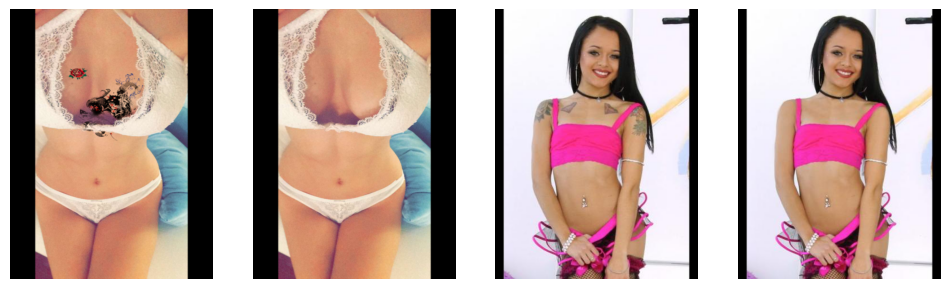

In [4]:
# Set up the DLs for the gen
dls_gen = get_dls(batch_size, image_size) 
dls_gen.show_batch(max_n=4, figsize=(12,12))
print(f"dls_gen items {len(dls_gen.dataset.items)}")

In [5]:
# Load the model
%store -r
try:
    # See if the model file name is present from a prior notebook run
    model_file = deinked_gen_model_file 
except  NameError:
    model_file = './deinked-xresnet34_deeper-epocs250.pkl'
    
print(f"Using gen model: {model_file}")
learn_gen = load_learner(model_file, cpu=not torch.cuda.is_available())

# Set the DLs into the gen learner
learn_gen.dls = dls_gen

#learn_gen.eval()

Using gen model: ./deinked-resnet18-epocs50.pkl


Total fnames: 425
383


/opt/conda/lib/python3.11/site-packages/fastai/data/transforms.py:225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if is_categorical_dtype(col):


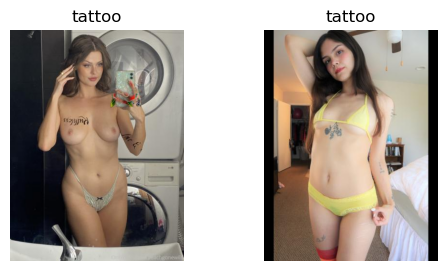

In [6]:
# Set up the DLs for the critic
print(f'Total fnames: {len(fnames)}') # from the 00 import
dls_crit = get_crit_dls(fnames, bs=batch_size, size=image_size)
dls_crit.show_batch()
print(len(dls_crit.dataset.items))

In [7]:
deinked_gen_critic_file

%store -r
try:
    # See if the model file name is present from a prior notebook run
    model_file = deinked_gen_critic_file 
except  NameError:
    model_file = './deinked-gen-critic-epocs200.pkl'
    
print(f"Using critic model: {model_file}")
learn_crit = load_learner(model_file, cpu=not torch.cuda.is_available())

learn_crit.dls = dls_crit

#learn_crit.eval()

Using critic model: ./deinked-gen-critic-epocs50.pkl


# Create the GAN

In [8]:
class GANDiscriminativeLR(Callback):
    "`Callback` that handles multiplying the learning rate by `mult_lr` for the critic."
    def __init__(self, mult_lr=5.): self.mult_lr = mult_lr

    def begin_batch(self):
        "Multiply the current lr if necessary."
        if not self.learn.gan_trainer.gen_mode and self.training: 
            self.learn.opt.set_hyper('lr', learn.opt.hypers[0]['lr']*self.mult_lr)

    def after_batch(self):
        "Put the LR back to its value if necessary."
        if not self.learn.gan_trainer.gen_mode: self.learn.opt.set_hyper('lr', learn.opt.hypers[0]['lr']/self.mult_lr)

In [9]:
switcher = AdaptiveGANSwitcher(critic_thresh=.65)

In [10]:
# What callbacks do we want
cbs = [ GANDiscriminativeLR(mult_lr=5.) ]
csv_append = True
if (start_epoch == 0):
    cbs.append(ShowGraphCallback())
    csv_append = False # overwrite whatever is there since we are starting at the beginning
    
# Add a logger to write to csv
cbs.append(CSVLogger(fname='history-gan.csv', append=csv_append))

learn = GANLearner.from_learners(learn_gen,
                                 learn_crit,
                                 weights_gen=(1.,50.),
                                 show_img=False,
                                 switcher=switcher,
                                 opt_func=partial(Adam, mom=0.),
                                 cbs=cbs)

# Do the learning

/opt/conda/lib/python3.11/site-packages/fastai/callback/core.py:69: UserWarning: You are shadowing an attribute (generator) that exists in the learner. Use `self.learn.generator` to avoid this
  warn(f"You are shadowing an attribute ({name}) that exists in the learner. Use `self.learn.{name}` to avoid this")
/opt/conda/lib/python3.11/site-packages/fastai/callback/core.py:69: UserWarning: You are shadowing an attribute (critic) that exists in the learner. Use `self.learn.critic` to avoid this
  warn(f"You are shadowing an attribute ({name}) that exists in the learner. Use `self.learn.{name}` to avoid this")
/opt/conda/lib/python3.11/site-packages/fastai/callback/core.py:69: UserWarning: You are shadowing an attribute (gen_mode) that exists in the learner. Use `self.learn.gen_mode` to avoid this
  warn(f"You are shadowing an attribute ({name}) that exists in the learner. Use `self.learn.{name}` to avoid this")


epoch,train_loss,valid_loss,gen_loss,crit_loss,time
0,0.693366,2.309140,2.309140,0.693688,00:26
1,0.693842,2.309141,2.309141,0.693654,00:26
2,0.694140,2.309141,2.309141,0.687433,00:26
3,0.698541,2.309141,2.309141,0.693676,00:26
4,0.695140,2.309140,2.309140,0.692102,00:26
5,0.694414,2.309141,2.309141,0.692797,00:26
6,0.694849,2.309140,2.309140,0.693323,00:26
7,0.699561,2.309141,2.309141,0.693039,00:26
8,0.695592,2.309141,2.309141,0.693664,00:26
9,0.695193,2.309140,2.309140,0.693057,00:26


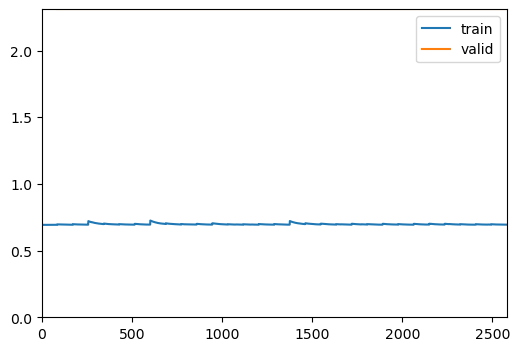

In [11]:
learn.fit(epocs, lr, wd=wd)

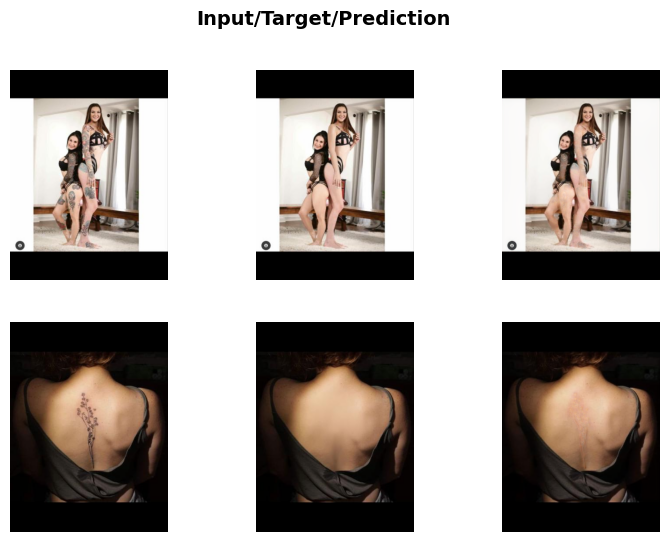

In [12]:
learn_gen.show_results(max_n=4)

# Save the Model

In [13]:
#save the model
#learn.export(f'./kitty-gen-gan-epocs{epocs}.pkl')
learn.save(f'./deinked-gan-epocs{epocs}')

Path('data/models/deinked-gan-epocs30.pth')

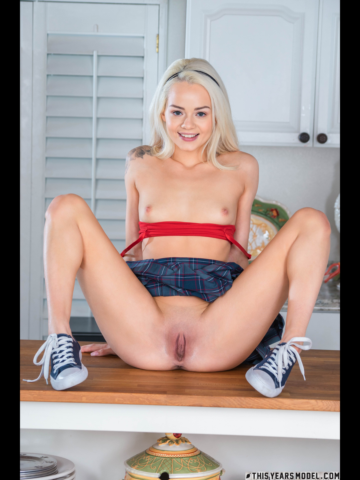

In [17]:
# Load a test file
images = [
    PILImage.create("./data/deinked/test/murka.png"),
    PILImage.create("./data/deinked/test/tovsakfozbea1.jpg"),
    PILImage.create("./data/deinked/test/vikki_ray.jpeg"),
    PILImage.create("./data/deinked/test/vic_lari.jpeg"),
    PILImage.create("./data/deinked/test/yumi_sin.jpeg"),
    PILImage.create("./data/deinked/test/zoe_faye.jpeg"),
    PILImage.create("./data/deinked/test/0010-15.jpg"),
    PILImage.create("./data/deinked/test/Elsa Jean.jpg"),
]
resize = Resize(image_size, 
                resamples=(Image.BILINEAR, Image.NEAREST),
                 method=ResizeMethod.Pad,
                 pad_mode=PadMode.Zeros)
img_fast = resize(images[7], split_idx=1)
display(img_fast)

In [18]:
# Run our prediction
tensor_image, img_hr_tensor_base, preds_tensor_base = learn_gen.predict(img_fast)

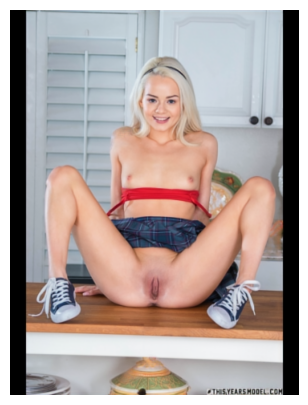

In [19]:
# Show our results
pil_image = PILImage.create(tensor_image)
pil_image.show()
pil_image.save("model-test.jpg")